# Milestone 2 (v0.2) — The GPSConv Model and Its Sanity Battery

In [1]:
import sys, json, time, warnings
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
ROOT = Path.cwd()
sys.path.insert(0, str(ROOT))

from gridfm import dataset as ds, encoding as enc, train as tr
from gridfm.model import GridFMv01, GridFMv02, count_parameters, gridfm_loss

PROC_DIR = ROOT / "data" / "processed"
FIG_DIR = ROOT / "results" / "figures" / "v02_m2"
STATS_DIR = ROOT / "results" / "v02_m2_stats"
FIG_DIR.mkdir(parents=True, exist_ok=True)
STATS_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE,
      f"({torch.cuda.get_device_name(0)})" if DEVICE == "cuda" else "")
torch.manual_seed(42); np.random.seed(42)

train_loader, val_loader = tr.make_loaders(PROC_DIR, ["case30"],
                                           transform=enc.concat_rwpe)
nb_train = len(train_loader.dataset); nb_val = len(val_loader.dataset)
print(f"case30 sanity data: {nb_train} train / {nb_val} val graphs, "
      f"x width {train_loader.dataset[0].x.shape[1]} (9 features + {enc.K_STEPS} RWPE)")

device: cuda (NVIDIA GeForce RTX 3050 Laptop GPU)


case30 sanity data: 1369 train / 174 val graphs, x width 25 (9 features + 16 RWPE)


## Step 1 — Instantiate: where the parameters live

In [2]:
model = GridFMv02().to(DEVICE)
n_v02 = count_parameters(model)
n_v01 = count_parameters(GridFMv01())
print(f"GridFMv02: {n_v02:,} parameters   (GridFMv01: {n_v01:,}, "
      f"{100 * (n_v02 - n_v01) / n_v01:+.1f}%)\n")

n_gine = sum(count_parameters(c.conv) for c in model.convs)
n_attn = sum(count_parameters(c.attn) for c in model.convs)
n_embed = count_parameters(model.embed); n_dec = count_parameters(model.decoder)
n_rest = n_v02 - n_gine - n_attn - n_embed - n_dec
for name, n in [("embed (25 -> 80)", n_embed),
                ("GINEConv, local channel (4 layers)", n_gine),
                ("global attention channel (4 layers)", n_attn),
                ("merge MLP + norms (4 layers)", n_rest),
                ("decoder (80 -> 80 -> 6)", n_dec)]:
    print(f"  {name:38s} {n:8,}  ({100 * n / n_v02:4.1f}%)")

# forward pass on one mixed mini-batch: shapes in, shapes out
b = next(iter(train_loader)).to(DEVICE)
xm, mask = ds.random_mask(b.x, generator=None)
pred = model(xm, b.edge_index, b.edge_attr, batch=b.batch)
print(f"\nbatch of {b.num_graphs} graphs: x {tuple(b.x.shape)} -> pred {tuple(pred.shape)}")

GridFMv02: 270,806 parameters   (GridFMv01: 283,782, -4.6%)

  embed (25 -> 80)                          2,080  ( 0.8%)
  GINEConv, local channel (4 layers)       52,800  (19.5%)
  global attention channel (4 layers)     103,680  (38.3%)
  merge MLP + norms (4 layers)            105,280  (38.9%)
  decoder (80 -> 80 -> 6)                   6,966  ( 2.6%)



batch of 64 graphs: x (1920, 25) -> pred (1920, 6)


## Step 2 — The loss battery

In [3]:
b_cpu = next(iter(val_loader))
xm_c, m_c = ds.random_mask(b_cpu.x, generator=torch.Generator().manual_seed(0))
b, xm, mask = b_cpu.to(DEVICE), xm_c.to(DEVICE), m_c.to(DEVICE)

# Check 1: ground truth as "prediction" -> PBE ~ float32 zero
loss_gt, parts_gt = gridfm_loss(b.x[:, :ds.N_ELECTRICAL], b.x, mask,
                                b.ybus_index, b.ybus_g, b.ybus_b)
print(f"Check 1  PBE at ground truth: {parts_gt['pbe']:.2e}  (float32 floor)")
assert parts_gt["pbe"] < 1e-8

# Check 2: untrained model -> large loss
model.eval()
with torch.no_grad():
    pred = model(xm, b.edge_index, b.edge_attr, batch=b.batch)
_, parts_rand = gridfm_loss(pred, b.x, mask, b.ybus_index, b.ybus_g, b.ybus_b)
print(f"Check 2  untrained model loss: total {parts_rand['total']:.1f} "
      f"(mse {parts_rand['mse']:.2f}, pbe {parts_rand['pbe']:.1f})")
assert parts_rand["total"] > 1.0

# Check 3: gradients reach every component of both channels
model.train()
model.zero_grad()
pred = model(xm, b.edge_index, b.edge_attr, batch=b.batch)
loss, _ = gridfm_loss(pred, b.x, mask, b.ybus_index, b.ybus_g, b.ybus_b)
loss.backward()
print("Check 3  gradient L2 norm per component:")
comps = {"embed": model.embed, "decoder": model.decoder}
for li, conv in enumerate(model.convs):
    comps[f"layer{li} GINE (local)"] = conv.conv
    comps[f"layer{li} attn (global)"] = conv.attn
    comps[f"layer{li} merge MLP"] = conv.mlp
for name, mod in comps.items():
    gn = torch.sqrt(sum(p.grad.pow(2).sum() for p in mod.parameters()
                        if p.grad is not None))
    print(f"  {name:24s} {float(gn):10.4f}")
    assert float(gn) > 0, f"dead component: {name}"
model.zero_grad()
print("all components receive gradient — no dead channel")

Check 1  PBE at ground truth: 8.93e-12  (float32 floor)
Check 2  untrained model loss: total 1293587.4 (mse 25.48, pbe 1306653.6)


Check 3  gradient L2 norm per component:
  embed                      249.0369
  decoder                   2324.2520
  layer0 GINE (local)       1639.2695
  layer0 attn (global)        94.9412
  layer0 merge MLP           329.5983
  layer1 GINE (local)        778.2130
  layer1 attn (global)        80.1237
  layer1 merge MLP           336.3435
  layer2 GINE (local)       1746.1711
  layer2 attn (global)       101.0287
  layer2 merge MLP           378.6775
  layer3 GINE (local)       1449.1270
  layer3 attn (global)       149.2248
  layer3 merge MLP           588.2593
all components receive gradient — no dead channel


## Step 3 — Sanity training run: 10 epochs, thesis learning rate, collapse watch

In [4]:
EPOCHS, LR, CLIP = 10, 1e-4, 1.0
torch.manual_seed(42)
model = GridFMv02().to(DEVICE)
opt = torch.optim.Adam(model.parameters(), lr=LR, betas=(0.9, 0.999))

def val_pass(model):
    """Validation loss + stats of predictions at masked |V| slots (fixed mask)."""
    model.eval()
    gen = torch.Generator().manual_seed(1234)
    sums, n = {"total": 0.0, "mse": 0.0, "pbe": 0.0}, 0
    vm_pred, vm_true = [], []
    with torch.no_grad():
        for b in val_loader:
            xm_c, m_c = ds.random_mask(b.x, generator=gen)   # mask on CPU: same gen as v0.1
            b, xm_c, m_c = b.to(DEVICE), xm_c.to(DEVICE), m_c.to(DEVICE)
            pred = model(xm_c, b.edge_index, b.edge_attr, batch=b.batch)
            _, parts = gridfm_loss(pred, b.x, m_c, b.ybus_index, b.ybus_g, b.ybus_b)
            for k in sums:
                sums[k] += parts[k] * b.num_graphs
            n += b.num_graphs
            vm = m_c[:, 4]
            vm_pred += pred[vm, 4].tolist(); vm_true += b.x[vm, 4].tolist()
    return ({k: v / n for k, v in sums.items()},
            float(np.mean(vm_pred)), float(np.std(vm_pred)),
            float(np.mean(vm_true)), float(np.std(vm_true)))

hist = []
t_start = time.time()
for epoch in range(EPOCHS):
    t0 = time.time()
    trm = tr.run_epoch(model, train_loader, DEVICE, opt=opt, clip=CLIP)
    vam, vp_mu, vp_sd, vt_mu, vt_sd = val_pass(model)
    hist.append({"epoch": epoch, "train": trm, "val": vam,
                 "vm_pred_mu": vp_mu, "vm_pred_sd": vp_sd,
                 "vm_true_mu": vt_mu, "vm_true_sd": vt_sd,
                 "sec": time.time() - t0})
    print(f"epoch {epoch:2d} | train {trm['total']:8.3f} | val {vam['total']:8.3f} "
          f"(mse {vam['mse']:.4f} pbe {vam['pbe']:.3f}) | masked |V| pred "
          f"{vp_mu:.3f}±{vp_sd:.3f} (true {vt_mu:.3f}±{vt_sd:.3f}) | {hist[-1]['sec']:.1f}s")
sec_per_epoch = (time.time() - t_start) / EPOCHS
print(f"\n{sec_per_epoch:.1f} s/epoch on {DEVICE} (case30 only, {nb_train} graphs)")

epoch  0 | train  156.306 | val   83.753 (mse 0.1366 pbe 84.597) | masked |V| pred 0.314±0.208 (true 0.998±0.017) | 1.2s


epoch  1 | train   79.134 | val   55.182 (mse 0.0951 pbe 55.738) | masked |V| pred 0.505±0.163 (true 0.998±0.017) | 1.1s


epoch  2 | train   46.778 | val   24.566 (mse 0.0678 pbe 24.813) | masked |V| pred 0.714±0.128 (true 0.998±0.017) | 1.0s


epoch  3 | train   29.868 | val   11.977 (mse 0.0534 pbe 12.098) | masked |V| pred 0.834±0.094 (true 0.998±0.017) | 1.0s


epoch  4 | train   19.701 | val    8.719 (mse 0.0462 pbe 8.807) | masked |V| pred 0.890±0.068 (true 0.998±0.017) | 1.0s


epoch  5 | train   14.868 | val    4.280 (mse 0.0441 pbe 4.323) | masked |V| pred 0.916±0.057 (true 0.998±0.017) | 1.2s


epoch  6 | train   10.441 | val    5.120 (mse 0.0390 pbe 5.171) | masked |V| pred 0.930±0.052 (true 0.998±0.017) | 1.0s


epoch  7 | train    8.631 | val    2.436 (mse 0.0397 pbe 2.460) | masked |V| pred 0.948±0.035 (true 0.998±0.017) | 1.0s


epoch  8 | train    6.837 | val    2.279 (mse 0.0373 pbe 2.302) | masked |V| pred 0.961±0.033 (true 0.998±0.017) | 1.0s


epoch  9 | train    5.781 | val    1.126 (mse 0.0326 pbe 1.137) | masked |V| pred 0.964±0.032 (true 0.998±0.017) | 1.0s

1.0 s/epoch on cuda (case30 only, 1369 graphs)


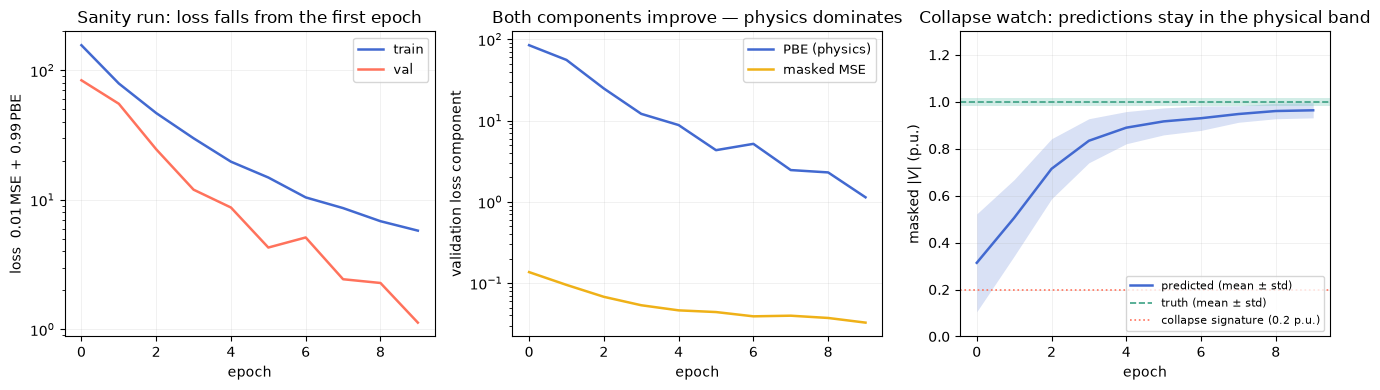

In [5]:
ep = [h["epoch"] for h in hist]
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.0))
axes[0].plot(ep, [h["train"]["total"] for h in hist], lw=1.8, color="#4269D0", label="train")
axes[0].plot(ep, [h["val"]["total"] for h in hist], lw=1.8, color="#FF725C", label="val")
axes[0].set(xlabel="epoch", ylabel="loss  $0.01\\,$MSE$\\,+\\,0.99\\,$PBE",
            title="Sanity run: loss falls from the first epoch", yscale="log")
axes[0].legend(fontsize=9)
axes[1].plot(ep, [h["val"]["pbe"] for h in hist], lw=1.8, color="#4269D0", label="PBE (physics)")
axes[1].plot(ep, [h["val"]["mse"] for h in hist], lw=1.8, color="#EFB118", label="masked MSE")
axes[1].set(xlabel="epoch", ylabel="validation loss component",
            title="Both components improve — physics dominates", yscale="log")
axes[1].legend(fontsize=9)
mu = np.array([h["vm_pred_mu"] for h in hist]); sd = np.array([h["vm_pred_sd"] for h in hist])
axes[2].fill_between(ep, mu - sd, mu + sd, color="#4269D0", alpha=0.20, lw=0)
axes[2].plot(ep, mu, lw=1.8, color="#4269D0", label="predicted (mean ± std)")
axes[2].axhspan(hist[0]["vm_true_mu"] - hist[0]["vm_true_sd"],
                hist[0]["vm_true_mu"] + hist[0]["vm_true_sd"],
                color="#6CC5B0", alpha=0.30, lw=0)
axes[2].axhline(hist[0]["vm_true_mu"], color="#3CA285", lw=1.2, ls="--", label="truth (mean ± std)")
axes[2].axhline(0.2, color="#FF725C", lw=1.2, ls=":", label="collapse signature (0.2 p.u.)")
axes[2].set(xlabel="epoch", ylabel="masked $|V|$ (p.u.)", ylim=(0.0, 1.3),
            title="Collapse watch: predictions stay in the physical band")
axes[2].legend(fontsize=8, loc="lower right")
for ax in axes:
    ax.grid(alpha=0.25, lw=0.5)
fig.tight_layout(); fig.savefig(FIG_DIR / "f1_sanity_training.png", bbox_inches="tight", dpi=150)
plt.show()

## Step 4 — What 10 epochs already buy: a reconstruction teaser

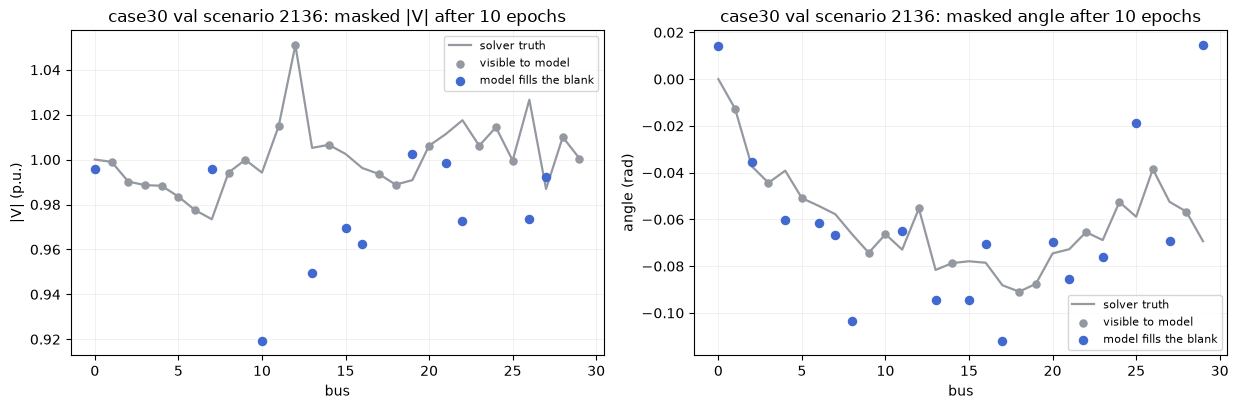

masked-slot MAE after 10 sanity epochs: |V| 0.0320 p.u., angle 0.0191 rad


In [6]:
g = val_loader.dataset[7].clone().to(DEVICE)
gen = torch.Generator().manual_seed(7)
xm_c, m_c = ds.random_mask(g.x.cpu(), generator=gen)
xm, m = xm_c.to(DEVICE), m_c.to(DEVICE)
model.eval()
with torch.no_grad():
    pred = model(xm, g.edge_index, g.edge_attr)

buses = np.arange(g.num_nodes)
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
for ax, col, name, unit in [(axes[0], 4, "|V|", "p.u."), (axes[1], 5, "angle", "rad")]:
    truth = g.x[:, col].cpu().numpy()
    mk = m[:, col].cpu().numpy().astype(bool)
    ax.plot(buses, truth, lw=1.6, color="#9498A0", label="solver truth", zorder=1)
    ax.scatter(buses[~mk], truth[~mk], s=26, color="#9498A0", zorder=2,
               label="visible to model")
    ax.scatter(buses[mk], pred.cpu().numpy()[mk, col], s=34, color="#4269D0",
               zorder=3, label="model fills the blank")
    ax.set(xlabel="bus", ylabel=f"{name} ({unit})",
           title=f"case30 val scenario {int(g.scenario)}: masked {name} after 10 epochs")
    ax.grid(alpha=0.25, lw=0.5); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIG_DIR / "f2_reconstruction_teaser.png", bbox_inches="tight", dpi=150)
plt.show()

vm_mae = float((pred[m[:, 4], 4] - g.x[m[:, 4], 4]).abs().mean())
va_mae = float((pred[m[:, 5], 5] - g.x[m[:, 5], 5]).abs().mean())
print(f"masked-slot MAE after 10 sanity epochs: |V| {vm_mae:.4f} p.u., angle {va_mae:.4f} rad")

In [7]:
stats = {"params_v02": n_v02, "params_v01": n_v01,
         "config": {"layers": 4, "hidden": 80, "heads": 4, "in_dim": 25,
                    "dropout": 0.1, "lr": LR, "clip": CLIP, "epochs": EPOCHS},
         "device": DEVICE,
         "sec_per_epoch_case30": round(sec_per_epoch, 2),
         "pbe_at_ground_truth": parts_gt["pbe"],
         "untrained_loss": parts_rand["total"],
         "final": {"train": hist[-1]["train"], "val": hist[-1]["val"],
                   "vm_pred_mu": hist[-1]["vm_pred_mu"],
                   "vm_pred_sd": hist[-1]["vm_pred_sd"],
                   "vm_true_mu": hist[-1]["vm_true_mu"]},
         "teaser_mae": {"vm_pu": vm_mae, "va_rad": va_mae}}
with open(STATS_DIR / "sanity.json", "w") as f:
    json.dump(stats, f, indent=2)
print(json.dumps(stats, indent=2))

{
  "params_v02": 270806,
  "params_v01": 283782,
  "config": {
    "layers": 4,
    "hidden": 80,
    "heads": 4,
    "in_dim": 25,
    "dropout": 0.1,
    "lr": 0.0001,
    "clip": 1.0,
    "epochs": 10
  },
  "device": "cuda",
  "sec_per_epoch_case30": 1.05,
  "pbe_at_ground_truth": 8.927365791056019e-12,
  "untrained_loss": 1293587.375,
  "final": {
    "train": {
      "total": 5.781075357781265,
      "mse": 0.03450654069651558,
      "pbe": 5.839121491130553
    },
    "val": {
      "total": 1.1262998991999134,
      "mse": 0.03264915857506895,
      "pbe": 1.1373468719679733
    },
    "vm_pred_mu": 0.9636489626004511,
    "vm_pred_sd": 0.03225129977180081,
    "vm_true_mu": 0.9977141885386999
  },
  "teaser_mae": {
    "vm_pu": 0.03203287720680237,
    "va_rad": 0.019133834168314934
  }
}
